In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import json
import pickle
import random
import numpy as np
import pandas as pd

from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    classification_report,
    confusion_matrix
)

SEEDS = [42, 123, 2024]

BASE_PROJECT = Path("/content/drive/MyDrive/New Jurnal Cross")

HC_DIR = BASE_PROJECT / "processed_intra_features_hc_noaug"
E2V_DIR = BASE_PROJECT / "processed_intra_features_e2v_plus_base"

OUT_DIR = BASE_PROJECT / "results_intra_concat_fusion_mlp_plus_base"
OUT_DIR.mkdir(parents=True, exist_ok=True)

DATASETS = ["emodb", "ravdess", "resd"]

LABELS = [
    "angry",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
]

ID_TO_LABEL = {i: label for i, label in enumerate(LABELS)}
LABEL_TO_ID = {label: i for i, label in ID_TO_LABEL.items()}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("DEVICE:", DEVICE)
print("HC_DIR :", HC_DIR)
print("E2V_DIR:", E2V_DIR)
print("OUT_DIR:", OUT_DIR)

for ds in DATASETS:
    print("=" * 60)
    print(ds)
    print("HC exists :", (HC_DIR / ds).exists())
    print("E2V exists:", (E2V_DIR / ds).exists())

DEVICE: cuda
HC_DIR : /content/drive/MyDrive/New Jurnal Cross/processed_intra_features_hc_noaug
E2V_DIR: /content/drive/MyDrive/New Jurnal Cross/processed_intra_features_e2v_plus_base
OUT_DIR: /content/drive/MyDrive/New Jurnal Cross/results_intra_concat_fusion_mlp_plus_base
emodb
HC exists : True
E2V exists: True
ravdess
HC exists : True
E2V exists: True
resd
HC exists : True
E2V exists: True


In [3]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def compute_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "uar": recall_score(y_true, y_pred, average="macro", zero_division=0),
    }


def make_report_df(y_true, y_pred):
    report = classification_report(
        y_true,
        y_pred,
        target_names=LABELS,
        labels=list(range(len(LABELS))),
        zero_division=0,
        output_dict=True
    )
    return pd.DataFrame(report).transpose()


def save_confusion_matrix_csv(cm, out_path):
    df_cm = pd.DataFrame(cm, index=LABELS, columns=LABELS)
    df_cm.to_csv(out_path, index=True)


def make_loader(X, y, batch_size=32, shuffle=False):
    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.long)

    dataset = TensorDataset(X_tensor, y_tensor)

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=False
    )


def compute_class_weights(y_train, n_classes=6):
    counts = np.bincount(y_train, minlength=n_classes).astype(np.float32)
    weights = counts.sum() / (n_classes * counts)
    weights = weights / weights.mean()
    return torch.tensor(weights, dtype=torch.float32)

In [4]:
def load_concat_dataset(dataset_name, scale=True):
    hc_ds = HC_DIR / dataset_name
    e2v_ds = E2V_DIR / dataset_name

    # Handcrafted
    X_hc_train = np.load(hc_ds / "X_hc_train.npy").astype(np.float32)
    X_hc_val = np.load(hc_ds / "X_hc_val.npy").astype(np.float32)
    X_hc_test = np.load(hc_ds / "X_hc_test.npy").astype(np.float32)

    y_hc_train = np.load(hc_ds / "y_train.npy").astype(np.int64)
    y_hc_val = np.load(hc_ds / "y_val.npy").astype(np.int64)
    y_hc_test = np.load(hc_ds / "y_test.npy").astype(np.int64)

    meta_hc_train = pd.read_csv(hc_ds / "meta_train.csv")
    meta_hc_val = pd.read_csv(hc_ds / "meta_val.csv")
    meta_hc_test = pd.read_csv(hc_ds / "meta_test.csv")

    # emotion2vec
    X_e2v_train = np.load(e2v_ds / "X_e2v_train.npy").astype(np.float32)
    X_e2v_val = np.load(e2v_ds / "X_e2v_val.npy").astype(np.float32)
    X_e2v_test = np.load(e2v_ds / "X_e2v_test.npy").astype(np.float32)

    y_e2v_train = np.load(e2v_ds / "y_train.npy").astype(np.int64)
    y_e2v_val = np.load(e2v_ds / "y_val.npy").astype(np.int64)
    y_e2v_test = np.load(e2v_ds / "y_test.npy").astype(np.int64)

    meta_e2v_train = pd.read_csv(e2v_ds / "meta_train.csv")
    meta_e2v_val = pd.read_csv(e2v_ds / "meta_val.csv")
    meta_e2v_test = pd.read_csv(e2v_ds / "meta_test.csv")

    # Safety checks
    assert X_hc_train.shape[0] == X_e2v_train.shape[0], "train N mismatch"
    assert X_hc_val.shape[0] == X_e2v_val.shape[0], "val N mismatch"
    assert X_hc_test.shape[0] == X_e2v_test.shape[0], "test N mismatch"

    assert np.array_equal(y_hc_train, y_e2v_train), "train labels mismatch"
    assert np.array_equal(y_hc_val, y_e2v_val), "val labels mismatch"
    assert np.array_equal(y_hc_test, y_e2v_test), "test labels mismatch"

    # UID check, kalau kolom uid tersedia
    for split_name, meta_hc, meta_e2v in [
        ("train", meta_hc_train, meta_e2v_train),
        ("val", meta_hc_val, meta_e2v_val),
        ("test", meta_hc_test, meta_e2v_test),
    ]:
        if "uid" in meta_hc.columns and "uid" in meta_e2v.columns:
            if not meta_hc["uid"].astype(str).equals(meta_e2v["uid"].astype(str)):
                raise ValueError(f"UID mismatch in {dataset_name} {split_name}")

    scaler_hc = None
    scaler_e2v = None

    if scale:
        scaler_hc = StandardScaler()
        X_hc_train = scaler_hc.fit_transform(X_hc_train).astype(np.float32)
        X_hc_val = scaler_hc.transform(X_hc_val).astype(np.float32)
        X_hc_test = scaler_hc.transform(X_hc_test).astype(np.float32)

        scaler_e2v = StandardScaler()
        X_e2v_train = scaler_e2v.fit_transform(X_e2v_train).astype(np.float32)
        X_e2v_val = scaler_e2v.transform(X_e2v_val).astype(np.float32)
        X_e2v_test = scaler_e2v.transform(X_e2v_test).astype(np.float32)

    X_train = np.concatenate([X_e2v_train, X_hc_train], axis=1).astype(np.float32)
    X_val = np.concatenate([X_e2v_val, X_hc_val], axis=1).astype(np.float32)
    X_test = np.concatenate([X_e2v_test, X_hc_test], axis=1).astype(np.float32)

    return {
        "X_train": X_train,
        "y_train": y_hc_train,
        "X_val": X_val,
        "y_val": y_hc_val,
        "X_test": X_test,
        "y_test": y_hc_test,
        "meta_train": meta_hc_train,
        "meta_val": meta_hc_val,
        "meta_test": meta_hc_test,
        "scaler_hc": scaler_hc,
        "scaler_e2v": scaler_e2v,
        "hc_dim": X_hc_train.shape[1],
        "e2v_dim": X_e2v_train.shape[1],
        "concat_dim": X_train.shape[1],
    }

In [5]:
for ds in DATASETS:
    data = load_concat_dataset(ds, scale=True)

    print("=" * 80)
    print(ds.upper())
    print("HC dim    :", data["hc_dim"])
    print("E2V dim   :", data["e2v_dim"])
    print("Concat dim:", data["concat_dim"])

    print("Train:", data["X_train"].shape, data["y_train"].shape)
    print("Val  :", data["X_val"].shape, data["y_val"].shape)
    print("Test :", data["X_test"].shape, data["y_test"].shape)

    print("NaN train:", np.isnan(data["X_train"]).any())
    print("NaN val  :", np.isnan(data["X_val"]).any())
    print("NaN test :", np.isnan(data["X_test"]).any())

EMODB
HC dim    : 548
E2V dim   : 768
Concat dim: 1316
Train: (498, 1316) (498,)
Val  : (71, 1316) (71,)
Test : (149, 1316) (149,)
NaN train: False
NaN val  : False
NaN test : False
RAVDESS
HC dim    : 548
E2V dim   : 768
Concat dim: 1316
Train: (704, 1316) (704,)
Val  : (176, 1316) (176,)
Test : (176, 1316) (176,)
NaN train: False
NaN val  : False
NaN test : False
RESD
HC dim    : 548
E2V dim   : 768
Concat dim: 1316
Train: (873, 1316) (873,)
Val  : (186, 1316) (186,)
Test : (139, 1316) (139,)
NaN train: False
NaN val  : False
NaN test : False


In [6]:
class ConcatFusionMLP(nn.Module):
    def __init__(
        self,
        input_dim,
        hidden_dim=512,
        num_classes=6,
        dropout=0.35
    ):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim // 2, hidden_dim // 4),
            nn.LayerNorm(hidden_dim // 4),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim // 4, num_classes)
        )

    def forward(self, x):
        return self.net(x)

In [7]:
def run_one_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None

    if is_train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    all_preds = []
    all_targets = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            if is_train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()

        total_loss += loss.item() * X_batch.size(0)

        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_targets.extend(y_batch.detach().cpu().numpy().tolist())

    avg_loss = total_loss / len(loader.dataset)
    metrics = compute_metrics(np.array(all_targets), np.array(all_preds))

    return avg_loss, metrics, np.array(all_targets), np.array(all_preds)


@torch.no_grad()
def predict_model(model, loader):
    model.eval()

    all_preds = []
    all_targets = []
    all_probs = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(DEVICE)

        logits = model(X_batch)
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy().tolist())
        all_targets.extend(y_batch.numpy().tolist())
        all_probs.extend(probs.cpu().numpy().tolist())

    return (
        np.array(all_targets),
        np.array(all_preds),
        np.array(all_probs)
    )

In [8]:
def train_eval_concat_mlp(
    dataset_name,
    seed,
    batch_size=32,
    lr=8e-4,
    weight_decay=1e-4,
    max_epochs=150,
    patience=20,
    scale=True
):
    set_seed(seed)

    data = load_concat_dataset(dataset_name, scale=scale)

    X_train = data["X_train"]
    y_train = data["y_train"]

    X_val = data["X_val"]
    y_val = data["y_val"]

    X_test = data["X_test"]
    y_test = data["y_test"]

    input_dim = X_train.shape[1]
    num_classes = len(LABELS)

    train_loader = make_loader(X_train, y_train, batch_size=batch_size, shuffle=True)
    val_loader = make_loader(X_val, y_val, batch_size=batch_size, shuffle=False)
    test_loader = make_loader(X_test, y_test, batch_size=batch_size, shuffle=False)

    model = ConcatFusionMLP(
        input_dim=input_dim,
        hidden_dim=512,
        num_classes=num_classes,
        dropout=0.35
    ).to(DEVICE)

    class_weights = compute_class_weights(y_train, n_classes=num_classes).to(DEVICE)

    criterion = nn.CrossEntropyLoss(weight=class_weights)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=5
    )

    best_val_macro_f1 = -1.0
    best_epoch = -1
    best_state = None
    no_improve = 0

    history = []

    for epoch in range(1, max_epochs + 1):
        train_loss, train_metrics, _, _ = run_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer=optimizer
        )

        val_loss, val_metrics, _, _ = run_one_epoch(
            model,
            val_loader,
            criterion,
            optimizer=None
        )

        scheduler.step(val_metrics["macro_f1"])

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            **{f"train_{k}": v for k, v in train_metrics.items()},
            **{f"val_{k}": v for k, v in val_metrics.items()},
            "lr": optimizer.param_groups[0]["lr"]
        }
        history.append(row)

        current = val_metrics["macro_f1"]

        if current > best_val_macro_f1:
            best_val_macro_f1 = current
            best_epoch = epoch
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            no_improve = 0
        else:
            no_improve += 1

        if epoch % 10 == 0 or epoch == 1:
            print(
                f"[{dataset_name} | seed={seed}] "
                f"Epoch {epoch:03d} | "
                f"train_loss={train_loss:.4f} | "
                f"val_loss={val_loss:.4f} | "
                f"val_macro_f1={val_metrics['macro_f1']:.4f} | "
                f"best={best_val_macro_f1:.4f}"
            )

        if no_improve >= patience:
            print(
                f"[{dataset_name} | seed={seed}] Early stopping at epoch {epoch}. "
                f"Best epoch: {best_epoch}, best val macro-F1: {best_val_macro_f1:.4f}"
            )
            break

    model.load_state_dict(best_state)

    y_val_true, y_val_pred, y_val_prob = predict_model(model, val_loader)
    y_test_true, y_test_pred, y_test_prob = predict_model(model, test_loader)

    val_metrics = compute_metrics(y_val_true, y_val_pred)
    test_metrics = compute_metrics(y_test_true, y_test_pred)

    run_dir = OUT_DIR / dataset_name / f"seed_{seed}"
    run_dir.mkdir(parents=True, exist_ok=True)

    torch.save(model.state_dict(), run_dir / "concat_fusion_mlp_model.pt")

    if data["scaler_hc"] is not None:
        with open(run_dir / "scaler_hc.pkl", "wb") as f:
            pickle.dump(data["scaler_hc"], f)

    if data["scaler_e2v"] is not None:
        with open(run_dir / "scaler_e2v.pkl", "wb") as f:
            pickle.dump(data["scaler_e2v"], f)

    with open(run_dir / "training_config.json", "w") as f:
        json.dump({
            "dataset": dataset_name,
            "seed": seed,
            "batch_size": batch_size,
            "lr": lr,
            "weight_decay": weight_decay,
            "max_epochs": max_epochs,
            "patience": patience,
            "best_epoch": best_epoch,
            "best_val_macro_f1": best_val_macro_f1,
            "input_dim": input_dim,
            "e2v_dim": data["e2v_dim"],
            "hc_dim": data["hc_dim"],
            "num_classes": num_classes,
            "model": "ConcatFusionMLP",
            "class_weighted_loss": True,
            "scale": scale,
            "concat_order": "emotion2vec_then_handcrafted"
        }, f, indent=2)

    pd.DataFrame(history).to_csv(run_dir / "training_history.csv", index=False)

    pd.DataFrame([{
        "dataset": dataset_name,
        "seed": seed,
        "split": "val",
        "best_epoch": best_epoch,
        **val_metrics
    }]).to_csv(run_dir / "val_metrics.csv", index=False)

    pd.DataFrame([{
        "dataset": dataset_name,
        "seed": seed,
        "split": "test",
        "best_epoch": best_epoch,
        **test_metrics
    }]).to_csv(run_dir / "test_metrics.csv", index=False)

    make_report_df(y_val_true, y_val_pred).to_csv(run_dir / "val_classification_report.csv")
    make_report_df(y_test_true, y_test_pred).to_csv(run_dir / "test_classification_report.csv")

    cm_val = confusion_matrix(y_val_true, y_val_pred, labels=list(range(len(LABELS))))
    cm_test = confusion_matrix(y_test_true, y_test_pred, labels=list(range(len(LABELS))))

    save_confusion_matrix_csv(cm_val, run_dir / "val_confusion_matrix.csv")
    save_confusion_matrix_csv(cm_test, run_dir / "test_confusion_matrix.csv")

    pred_val_df = data["meta_val"].copy()
    pred_val_df["y_true"] = y_val_true
    pred_val_df["y_pred"] = y_val_pred
    pred_val_df["true_label"] = [ID_TO_LABEL[i] for i in y_val_true]
    pred_val_df["pred_label"] = [ID_TO_LABEL[i] for i in y_val_pred]
    for i, label in enumerate(LABELS):
        pred_val_df[f"prob_{label}"] = y_val_prob[:, i]
    pred_val_df.to_csv(run_dir / "val_predictions.csv", index=False)

    pred_test_df = data["meta_test"].copy()
    pred_test_df["y_true"] = y_test_true
    pred_test_df["y_pred"] = y_test_pred
    pred_test_df["true_label"] = [ID_TO_LABEL[i] for i in y_test_true]
    pred_test_df["pred_label"] = [ID_TO_LABEL[i] for i in y_test_pred]
    for i, label in enumerate(LABELS):
        pred_test_df[f"prob_{label}"] = y_test_prob[:, i]
    pred_test_df.to_csv(run_dir / "test_predictions.csv", index=False)

    row_val = {
        "dataset": dataset_name,
        "seed": seed,
        "split": "val",
        "best_epoch": best_epoch,
        **val_metrics
    }

    row_test = {
        "dataset": dataset_name,
        "seed": seed,
        "split": "test",
        "best_epoch": best_epoch,
        **test_metrics
    }

    return row_val, row_test

In [9]:
all_rows = []

for dataset_name in DATASETS:
    print("=" * 100)
    print(f"DATASET: {dataset_name.upper()}")
    print("=" * 100)

    for seed in SEEDS:
        print(f"\nTraining concat fusion MLP | dataset={dataset_name} | seed={seed}")

        row_val, row_test = train_eval_concat_mlp(
            dataset_name=dataset_name,
            seed=seed,
            batch_size=32,
            lr=8e-4,
            weight_decay=1e-4,
            max_epochs=150,
            patience=20,
            scale=True
        )

        all_rows.append(row_val)
        all_rows.append(row_test)

        print("VAL :", {k: round(v, 4) for k, v in row_val.items() if isinstance(v, float)})
        print("TEST:", {k: round(v, 4) for k, v in row_test.items() if isinstance(v, float)})

results = pd.DataFrame(all_rows)
results.to_csv(OUT_DIR / "all_seed_results.csv", index=False)

display(results)
print("Saved:", OUT_DIR / "all_seed_results.csv")

DATASET: EMODB

Training concat fusion MLP | dataset=emodb | seed=42
[emodb | seed=42] Epoch 001 | train_loss=0.9856 | val_loss=0.8127 | val_macro_f1=0.7528 | best=0.7528
[emodb | seed=42] Epoch 010 | train_loss=0.0802 | val_loss=1.1064 | val_macro_f1=0.7512 | best=0.7528
[emodb | seed=42] Epoch 020 | train_loss=0.0326 | val_loss=1.2328 | val_macro_f1=0.7413 | best=0.7992
[emodb | seed=42] Epoch 030 | train_loss=0.0095 | val_loss=1.4174 | val_macro_f1=0.7115 | best=0.7992
[emodb | seed=42] Early stopping at epoch 38. Best epoch: 18, best val macro-F1: 0.7992
VAL : {'accuracy': 0.8028, 'macro_f1': 0.7992, 'weighted_f1': 0.7965, 'uar': 0.8096}
TEST: {'accuracy': 0.9262, 'macro_f1': 0.9275, 'weighted_f1': 0.9266, 'uar': 0.9267}

Training concat fusion MLP | dataset=emodb | seed=123
[emodb | seed=123] Epoch 001 | train_loss=0.9122 | val_loss=0.9000 | val_macro_f1=0.6861 | best=0.6861
[emodb | seed=123] Epoch 010 | train_loss=0.0685 | val_loss=1.0814 | val_macro_f1=0.7677 | best=0.7716
[emo

,dataset,seed,split,best_epoch,accuracy,macro_f1,weighted_f1,uar
0,emodb,42,val,18,0.802817,0.799220,0.796546,0.809635
1,emodb,42,test,18,0.926174,0.927518,0.926557,0.926694
2,emodb,123,val,5,0.774648,0.771566,0.768040,0.783994
3,emodb,123,test,5,0.926174,0.927713,0.926701,0.925569
4,emodb,2024,val,15,0.802817,0.797864,0.792883,0.809635
5,emodb,2024,test,15,0.946309,0.947397,0.946414,0.946615
6,ravdess,42,val,9,0.914773,0.909097,0.917150,0.921875
7,ravdess,42,test,9,0.960227,0.957725,0.959943,0.953125
8,ravdess,123,val,3,0.920455,0.913146,0.923432,0.927083
9,ravdess,123,test,3,0.977273,0.973334,0.976970,0.968750


Saved: /content/drive/MyDrive/New Jurnal Cross/results_intra_concat_fusion_mlp_plus_base/all_seed_results.csv


In [10]:
metrics = ["accuracy", "macro_f1", "weighted_f1", "uar"]

summary_rows = []

for dataset_name in DATASETS:
    for split in ["val", "test"]:
        sub = results[
            (results["dataset"] == dataset_name) &
            (results["split"] == split)
        ]

        row = {
            "dataset": dataset_name,
            "split": split,
            "n_seeds": len(sub),
            "best_epoch_mean": sub["best_epoch"].mean(),
            "best_epoch_std": sub["best_epoch"].std(ddof=1),
        }

        for metric in metrics:
            row[f"{metric}_mean"] = sub[metric].mean()
            row[f"{metric}_std"] = sub[metric].std(ddof=1)

        summary_rows.append(row)

summary = pd.DataFrame(summary_rows)
summary.to_csv(OUT_DIR / "summary_mean_std.csv", index=False)

display(summary)
print("Saved:", OUT_DIR / "summary_mean_std.csv")

,dataset,split,n_seeds,best_epoch_mean,best_epoch_std,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,weighted_f1_mean,weighted_f1_std,uar_mean,uar_std
0,emodb,val,3,12.666667,6.806859,0.793427,0.016263,0.789550,0.015589,0.785823,0.015509,0.801088,0.014804
1,emodb,test,3,12.666667,6.806859,0.932886,0.011625,0.934209,0.011421,0.933224,0.011423,0.932959,0.011840
2,ravdess,val,3,4.666667,3.785939,0.918561,0.003280,0.911796,0.002338,0.921338,0.003627,0.925347,0.003007
3,ravdess,test,3,4.666667,3.785939,0.973485,0.011828,0.969896,0.010867,0.973220,0.011855,0.965278,0.010842
4,resd,val,3,1.666667,1.154701,0.634409,0.005376,0.624625,0.006293,0.622813,0.006740,0.633135,0.005740
5,resd,test,3,1.666667,1.154701,0.609113,0.010989,0.584516,0.007936,0.606941,0.008418,0.610748,0.009331


Saved: /content/drive/MyDrive/New Jurnal Cross/results_intra_concat_fusion_mlp_plus_base/summary_mean_std.csv


In [11]:
def mean_std_str(mean, std, scale=100):
    return f"{mean * scale:.2f} ± {std * scale:.2f}"


paper_rows = []

for dataset_name in DATASETS:
    sub = summary[
        (summary["dataset"] == dataset_name) &
        (summary["split"] == "test")
    ].iloc[0]

    paper_rows.append({
        "Dataset": dataset_name.upper(),
        "Accuracy": mean_std_str(sub["accuracy_mean"], sub["accuracy_std"]),
        "UAR": mean_std_str(sub["uar_mean"], sub["uar_std"]),
        "Macro-F1": mean_std_str(sub["macro_f1_mean"], sub["macro_f1_std"]),
        "Weighted-F1": mean_std_str(sub["weighted_f1_mean"], sub["weighted_f1_std"]),
        "Best Epoch": f"{sub['best_epoch_mean']:.1f} ± {sub['best_epoch_std']:.1f}",
    })

paper_table = pd.DataFrame(paper_rows)
paper_table.to_csv(OUT_DIR / "paper_table_test_mean_std.csv", index=False)

display(paper_table)
print("Saved:", OUT_DIR / "paper_table_test_mean_std.csv")

,Dataset,Accuracy,UAR,Macro-F1,Weighted-F1,Best Epoch
0,EMODB,93.29 ± 1.16,93.30 ± 1.18,93.42 ± 1.14,93.32 ± 1.14,12.7 ± 6.8
1,RAVDESS,97.35 ± 1.18,96.53 ± 1.08,96.99 ± 1.09,97.32 ± 1.19,4.7 ± 3.8
2,RESD,60.91 ± 1.10,61.07 ± 0.93,58.45 ± 0.79,60.69 ± 0.84,1.7 ± 1.2


Saved: /content/drive/MyDrive/New Jurnal Cross/results_intra_concat_fusion_mlp_plus_base/paper_table_test_mean_std.csv


In [12]:
per_class_rows = []

for dataset_name in DATASETS:
    for seed in SEEDS:
        report_path = OUT_DIR / dataset_name / f"seed_{seed}" / "test_classification_report.csv"
        report = pd.read_csv(report_path, index_col=0)

        for label in LABELS:
            per_class_rows.append({
                "dataset": dataset_name,
                "seed": seed,
                "class": label,
                "precision": report.loc[label, "precision"],
                "recall": report.loc[label, "recall"],
                "f1": report.loc[label, "f1-score"],
                "support": report.loc[label, "support"],
            })

per_class_df = pd.DataFrame(per_class_rows)
per_class_df.to_csv(OUT_DIR / "per_class_test_all_seeds.csv", index=False)

per_class_summary = (
    per_class_df
    .groupby(["dataset", "class"])
    .agg(
        precision_mean=("precision", "mean"),
        precision_std=("precision", "std"),
        recall_mean=("recall", "mean"),
        recall_std=("recall", "std"),
        f1_mean=("f1", "mean"),
        f1_std=("f1", "std"),
        support_mean=("support", "mean"),
    )
    .reset_index()
)

per_class_summary.to_csv(OUT_DIR / "per_class_test_summary_mean_std.csv", index=False)

display(per_class_summary)
print("Saved:", OUT_DIR / "per_class_test_summary_mean_std.csv")

,dataset,class,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,support_mean
0,emodb,angry,0.965517,0.000000,0.965517,0.000000,0.965517,0.000000,29.0
1,emodb,disgust,0.984848,0.026243,0.954545,0.000000,0.969345,0.012816,22.0
2,emodb,fear,0.855385,0.021538,0.866667,0.023094,0.860915,0.020063,25.0
3,emodb,happy,0.917778,0.001925,0.930556,0.024056,0.924036,0.012765,24.0
4,emodb,neutral,1.000000,0.000000,0.954545,0.045455,0.976375,0.023812,22.0
5,emodb,sad,0.893176,0.033458,0.925926,0.037037,0.909067,0.031575,27.0
6,ravdess,angry,1.000000,0.000000,0.927083,0.047735,0.961734,0.025924,32.0
7,ravdess,disgust,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,32.0
8,ravdess,fear,0.951804,0.059207,0.989583,0.018042,0.969996,0.039403,32.0
9,ravdess,happy,0.969697,0.000000,1.000000,0.000000,0.984615,0.000000,32.0


Saved: /content/drive/MyDrive/New Jurnal Cross/results_intra_concat_fusion_mlp_plus_base/per_class_test_summary_mean_std.csv


In [13]:
for dataset_name in DATASETS:
    cms = []

    for seed in SEEDS:
        cm_path = OUT_DIR / dataset_name / f"seed_{seed}" / "test_confusion_matrix.csv"
        cm = pd.read_csv(cm_path, index_col=0).values
        cms.append(cm)

    cm_mean = np.mean(cms, axis=0)
    cm_std = np.std(cms, axis=0, ddof=1)

    cm_mean_df = pd.DataFrame(cm_mean, index=LABELS, columns=LABELS)
    cm_std_df = pd.DataFrame(cm_std, index=LABELS, columns=LABELS)

    ds_out = OUT_DIR / dataset_name
    cm_mean_df.to_csv(ds_out / "test_confusion_matrix_mean.csv")
    cm_std_df.to_csv(ds_out / "test_confusion_matrix_std.csv")

    print("=" * 80)
    print(dataset_name.upper())
    print("Mean confusion matrix:")
    display(cm_mean_df.round(2))

    print("Std confusion matrix:")
    display(cm_std_df.round(2))

EMODB
Mean confusion matrix:


,angry,disgust,fear,happy,neutral,sad
angry,28.0,0.00,0.00,1.00,0.0,0.00
disgust,0.0,21.00,1.00,0.00,0.0,0.00
fear,0.0,0.00,21.67,1.00,0.0,2.33
happy,1.0,0.00,0.67,22.33,0.0,0.00
neutral,0.0,0.00,0.33,0.00,21.0,0.67
sad,0.0,0.33,1.67,0.00,0.0,25.00


Std confusion matrix:


,angry,disgust,fear,happy,neutral,sad
angry,0.0,0.00,0.00,0.00,0.0,0.00
disgust,0.0,0.00,0.00,0.00,0.0,0.00
fear,0.0,0.00,0.58,0.00,0.0,0.58
happy,0.0,0.00,0.58,0.58,0.0,0.00
neutral,0.0,0.00,0.58,0.00,1.0,0.58
sad,0.0,0.58,0.58,0.00,0.0,1.00


RAVDESS
Mean confusion matrix:


...

,angry,disgust,fear,happy,neutral,sad
angry,1.53,0.0,2.08,0.58,0.0,0.0
disgust,0.00,0.0,0.00,0.00,0.0,0.0
fear,0.00,0.0,0.58,0.58,0.0,0.0
happy,0.00,0.0,0.00,0.00,0.0,0.0
neutral,0.00,0.0,0.00,0.00,0.0,0.0
sad,0.00,0.0,0.00,0.00,0.0,0.0


RESD
Mean confusion matrix:


,angry,disgust,fear,happy,neutral,sad
angry,19.33,2.67,0.67,8.67,1.33,1.33
disgust,0.00,5.67,1.00,3.33,1.33,3.67
fear,0.00,4.00,11.67,0.67,5.67,7.00
happy,0.00,0.33,0.33,22.00,0.00,0.33
neutral,0.00,0.33,0.00,2.00,15.33,2.33
sad,0.67,1.67,0.00,1.00,4.00,10.67


Std confusion matrix:


,angry,disgust,fear,happy,neutral,sad
angry,0.58,1.15,1.15,1.53,0.58,1.15
disgust,0.00,0.58,0.00,0.58,0.58,0.58
fear,0.00,0.00,0.58,0.58,1.53,1.00
happy,0.00,0.58,0.58,1.73,0.00,0.58
neutral,0.00,0.58,0.00,0.00,1.53,1.15
sad,0.58,0.58,0.00,1.00,2.00,0.58


In [14]:
SVM_DIR = BASE_PROJECT / "results_intra_handcrafted_svm"
HC_MLP_DIR = BASE_PROJECT / "results_intra_handcrafted_mlp"
E2V_MLP_DIR = BASE_PROJECT / "results_intra_emotion2vec_mlp_plus_base"
CONCAT_DIR = BASE_PROJECT / "results_intra_concat_fusion_mlp_plus_base"

svm_summary = pd.read_csv(SVM_DIR / "summary_mean_std.csv")
hc_mlp_summary = pd.read_csv(HC_MLP_DIR / "summary_mean_std.csv")
e2v_summary = pd.read_csv(E2V_MLP_DIR / "summary_mean_std.csv")
concat_summary = pd.read_csv(CONCAT_DIR / "summary_mean_std.csv")

svm_test = svm_summary[svm_summary["split"] == "test"].copy()
hc_mlp_test = hc_mlp_summary[hc_mlp_summary["split"] == "test"].copy()
e2v_test = e2v_summary[e2v_summary["split"] == "test"].copy()
concat_test = concat_summary[concat_summary["split"] == "test"].copy()

svm_test["model"] = "Handcrafted SVM-RBF"
hc_mlp_test["model"] = "Handcrafted MLP"
e2v_test["model"] = "emotion2vec MLP"
concat_test["model"] = "Concat Fusion MLP"

compare = pd.concat(
    [svm_test, hc_mlp_test, e2v_test, concat_test],
    ignore_index=True
)

cols = [
    "model",
    "dataset",
    "accuracy_mean",
    "accuracy_std",
    "uar_mean",
    "uar_std",
    "macro_f1_mean",
    "macro_f1_std",
    "weighted_f1_mean",
    "weighted_f1_std",
]

compare = compare[cols]
compare.to_csv(CONCAT_DIR / "compare_all_intra_test.csv", index=False)

display(compare)
print("Saved:", CONCAT_DIR / "compare_all_intra_test.csv")

,model,dataset,accuracy_mean,accuracy_std,uar_mean,uar_std,macro_f1_mean,macro_f1_std,weighted_f1_mean,weighted_f1_std
0,Handcrafted SVM-RBF,emodb,0.765101,0.000000e+00,0.771862,0.000000,0.770845,0.000000,0.766550,0.000000
1,Handcrafted SVM-RBF,ravdess,0.585227,0.000000e+00,0.572917,0.000000,0.562632,0.000000,0.575213,0.000000
2,Handcrafted SVM-RBF,resd,0.230216,0.000000e+00,0.216041,0.000000,0.177384,0.000000,0.201610,0.000000
3,Handcrafted MLP,emodb,0.722595,5.125924e-02,0.722497,0.057131,0.724663,0.053999,0.723408,0.052484
4,Handcrafted MLP,ravdess,0.564394,3.280399e-03,0.576389,0.003007,0.556696,0.007691,0.556044,0.004402
5,Handcrafted MLP,resd,0.213429,3.244065e-02,0.205268,0.026294,0.208880,0.041376,0.228542,0.040862
6,emotion2vec MLP,emodb,0.914989,1.397091e-02,0.914272,0.015576,0.915618,0.014075,0.914662,0.013859
7,emotion2vec MLP,ravdess,0.977273,1.359740e-16,0.968750,0.000000,0.973412,0.000000,0.977055,0.000000
8,emotion2vec MLP,resd,0.565947,1.497601e-02,0.567849,0.019836,0.546025,0.017867,0.566678,0.015246
9,Concat Fusion MLP,emodb,0.932886,1.162450e-02,0.932959,0.011840,0.934209,0.011421,0.933224,0.011423


Saved: /content/drive/MyDrive/New Jurnal Cross/results_intra_concat_fusion_mlp_plus_base/compare_all_intra_test.csv


In [15]:
!pip -q install torchinfo torchviz graphviz

In [16]:
from torchinfo import summary

# Dummy model concat fusion
dummy_model = ConcatFusionMLP(
    input_dim=1316,
    hidden_dim=512,
    num_classes=6,
    dropout=0.35
).to(DEVICE)

summary(
    dummy_model,
    input_size=(32, 1316),  # batch_size=32, feature_dim=1316
    col_names=["input_size", "output_size", "num_params", "trainable"],
    depth=4
)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
ConcatFusionMLP                          [32, 1316]                [32, 6]                   --                        True
├─Sequential: 1-1                        [32, 1316]                [32, 6]                   --                        True
│    └─Linear: 2-1                       [32, 1316]                [32, 512]                 674,304                   True
│    └─LayerNorm: 2-2                    [32, 512]                 [32, 512]                 1,024                     True
│    └─ReLU: 2-3                         [32, 512]                 [32, 512]                 --                        --
│    └─Dropout: 2-4                      [32, 512]                 [32, 512]                 --                        --
│    └─Linear: 2-5                       [32, 512]                 [32, 256]                 131,328                   True
│    └─

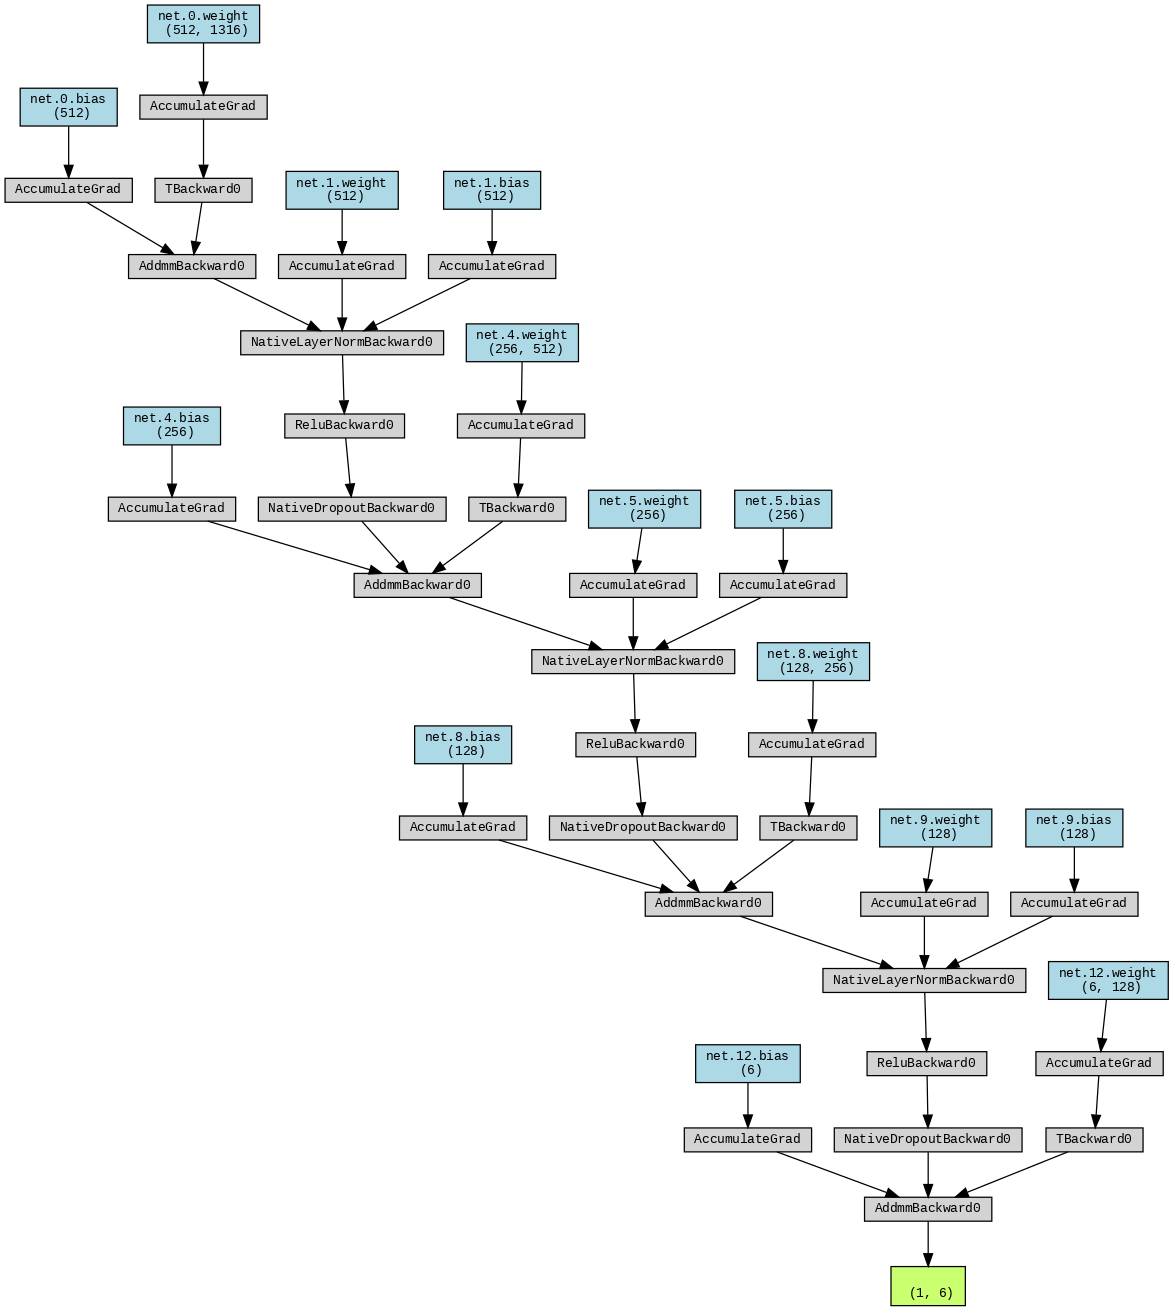

In [17]:
from torchviz import make_dot
from IPython.display import Image, display

# Buat dummy input
dummy_x = torch.randn(1, 1316).to(DEVICE)

# Forward pass
dummy_y = dummy_model(dummy_x)

# Buat graph
dot = make_dot(
    dummy_y,
    params=dict(dummy_model.named_parameters())
)

# Simpan graph
plot_path = OUT_DIR / "concat_fusion_mlp_architecture"

dot.format = "png"
dot.render(str(plot_path), cleanup=True)

# Tampilkan di notebook
display(Image(filename=str(plot_path) + ".png"))

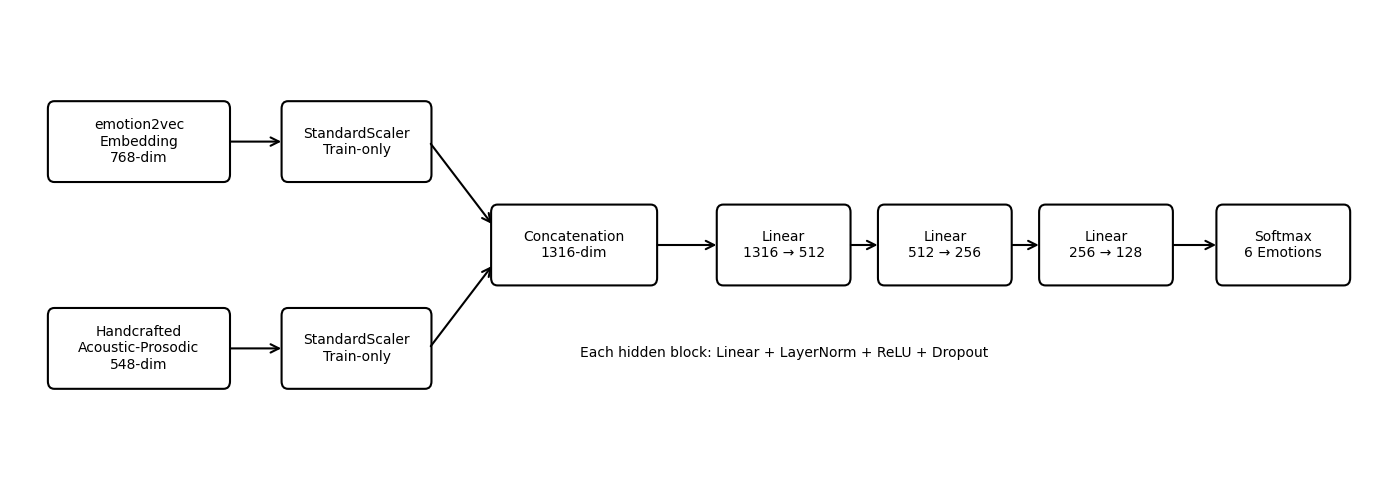

Saved: /content/drive/MyDrive/New Jurnal Cross/results_intra_concat_fusion_mlp_plus_base/concat_fusion_architecture_simple.png


In [18]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

def draw_concat_fusion_architecture(save_path=None):
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.set_xlim(0, 14)
    ax.set_ylim(0, 5)
    ax.axis("off")

    def box(x, y, w, h, text, fontsize=10):
        rect = FancyBboxPatch(
            (x, y), w, h,
            boxstyle="round,pad=0.03,rounding_size=0.08",
            linewidth=1.5,
            edgecolor="black",
            facecolor="white"
        )
        ax.add_patch(rect)
        ax.text(
            x + w / 2, y + h / 2,
            text,
            ha="center",
            va="center",
            fontsize=fontsize
        )

    def arrow(x1, y1, x2, y2):
        arr = FancyArrowPatch(
            (x1, y1), (x2, y2),
            arrowstyle="->",
            mutation_scale=15,
            linewidth=1.5,
            color="black"
        )
        ax.add_patch(arr)

    # Input branches
    box(0.5, 3.2, 2.2, 0.8, "emotion2vec\nEmbedding\n768-dim")
    box(0.5, 1.0, 2.2, 0.8, "Handcrafted\nAcoustic-Prosodic\n548-dim")

    # Scalers
    box(3.4, 3.2, 1.8, 0.8, "StandardScaler\nTrain-only")
    box(3.4, 1.0, 1.8, 0.8, "StandardScaler\nTrain-only")

    # Concatenation
    box(6.0, 2.1, 2.0, 0.8, "Concatenation\n1316-dim")

    # MLP
    box(8.8, 2.1, 1.6, 0.8, "Linear\n1316 → 512")
    box(10.8, 2.1, 1.6, 0.8, "Linear\n512 → 256")
    box(12.8, 2.1, 1.6, 0.8, "Linear\n256 → 128")

    # Output
    box(15.0, 2.1, 1.6, 0.8, "Softmax\n6 Emotions")

    # Adjust xlim because output is at 15
    ax.set_xlim(0, 17)

    # Arrows
    arrow(2.7, 3.6, 3.4, 3.6)
    arrow(2.7, 1.4, 3.4, 1.4)

    arrow(5.2, 3.6, 6.0, 2.7)
    arrow(5.2, 1.4, 6.0, 2.3)

    arrow(8.0, 2.5, 8.8, 2.5)
    arrow(10.4, 2.5, 10.8, 2.5)
    arrow(12.4, 2.5, 12.8, 2.5)
    arrow(14.4, 2.5, 15.0, 2.5)

    ax.text(
        9.6, 1.35,
        "Each hidden block: Linear + LayerNorm + ReLU + Dropout",
        ha="center",
        va="center",
        fontsize=10
    )

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


save_path = OUT_DIR / "concat_fusion_architecture_simple.png"
draw_concat_fusion_architecture(save_path=save_path)

print("Saved:", save_path)